<a href="https://colab.research.google.com/github/agustinargallardo-data/financial-intelligence-app/blob/main/02_expense_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Expense Prediction
This notebook explores a simple model to predict future monthly expenses based on historical data.

In [21]:
%%writefile transactions.csv
date,amount,type,category,description
2025-01-01,1200,income,salary,Monthly salary
2025-01-02,300,expense,food,Groceries
2025-01-03,50,expense,transport,Uber ride
2025-01-05,120,expense,entertainment,Movies
2025-01-07,700,expense,rent,January rent
2025-01-10,80,expense,health,Pharmacy
2025-01-12,150,expense,education,Online course
2025-01-15,200,income,freelance,Freelance work
2025-01-18,60,expense,food,Restaurant

Overwriting transactions.csv


In [22]:
import pandas as pd
df = pd.read_csv("transactions.csv")

In [23]:
df["date"] = pd.to_datetime(df["date"])
expenses = df[df["type"] == "expense"]
expenses["month"] = expenses["date"].dt.to_period("M")
monthly_expenses = (
    expenses
    .groupby("month")["amount"]
    .sum()
    .reset_index()
)
monthly_expenses

/tmp/ipython-input-548999496.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expenses["month"] = expenses["date"].dt.to_period("M")


,month,amount
0,2025-01,1460


In [24]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [25]:
monthly_expenses["month_index"] = np.arange(len(monthly_expenses))

X = monthly_expenses[["month_index"]]
y = monthly_expenses["amount"]

model = LinearRegression()
model.fit(X, y)

monthly_expenses["predicted"] = model.predict(X)
monthly_expenses

,month,amount,month_index,predicted
0,2025-01,1460,0,1460.0


In [26]:
type(model)

sklearn.linear_model._base.LinearRegression

In [27]:
# Predict next month
next_month_index = [[monthly_expenses["month_index"].max() + 1]]
next_month_prediction = model.predict(next_month_index)

next_month_prediction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1460.])

In [28]:
print(f"Predicted expenses for next month: {next_month_prediction[0]:.2f}")


Predicted expenses for next month: 1460.00


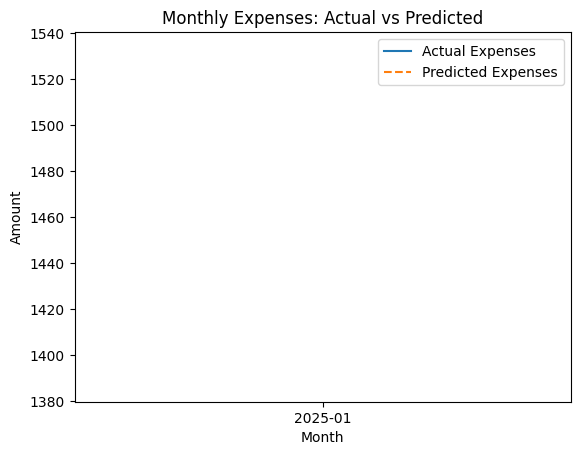

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(
monthly_expenses["month"].astype(str),
monthly_expenses["amount"],
label="Actual Expenses"
)

plt.plot(
monthly_expenses["month"].astype(str),
monthly_expenses["predicted"],
label="Predicted Expenses",
linestyle="--"
)

plt.legend()
plt.title("Monthly Expenses: Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

## Conclusion

In this project, I analyzed personal financial transactions to better understand spending behavior.
After cleaning and aggregating the data on a monthly basis, I applied a simple Linear Regression model
to identify trends and predict future expenses.

While the dataset is small and the model is intentionally simple, this project demonstrates:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering for time series
- Training and interpreting a machine learning model
- Visualizing results clearly

Future improvements could include:
- Adding more historical data
- Using more advanced time-series models
- Automating financial recommendations

# Financial Recommendations

In [30]:
total_income = df[df["type"] == "income"]["amount"].sum()
total_expenses = df[df["type"] == "expense"]["amount"].sum()
recommendations = []
if total_expenses > total_income:
  recommendations.append(
      "Your expenses are higher than your income. Consider reducing non-essential spending."
  )
  category_expenses = df[df["type"] == "expense"].groupby("category")["amount"].sum()
  for category, amount in category_expenses.items():
    if amount / total_expenses > 0.3:
      recommendations.append(
          f"You spend a high proportion of your money on {category}. You may want to review this category."
      )
      recommendations

In [31]:
print(recommendations)

['Your expenses are higher than your income. Consider reducing non-essential spending.', 'You spend a high proportion of your money on rent. You may want to review this category.']
